# Machine Learning project autumn 2024

Authors: Dimitar Kochev, Mihael Stoyanov <br>

Reqired imports:



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.preprocessing import StandardScaler
from sklearn import tree
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten,Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix
import pickle
from sklearn.model_selection import GridSearchCV
from collections import Counter


# Exploratory data analysis

### Load data:

In [2]:
train_data = np.load('Data+Description\\fashion_train.npy')
test_data = np.load('Data+Description\\fashion_test.npy')

In [3]:
# Devide features and labels
train_data_X=train_data[:,:-1]
train_data_y=train_data[:,-1]
#train_data_X=train_data_X / 255.0 #Scale pixel values to [0, 1]
test_data_X=test_data[:,:-1]
test_data_y=test_data[:,-1]

## Visualisations
### Distribution of classes in train set

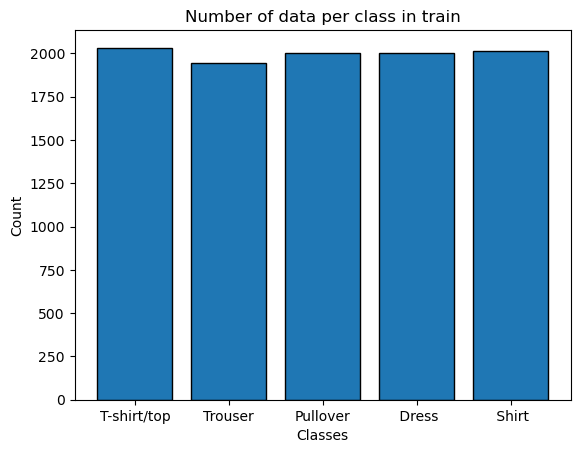

In [4]:
categories = ['T-shirt/top', 'Trouser', 'Pullover', ' Dress', ' Shirt']

# Plot the histogram
plt.hist(train_data_y, bins=np.arange(6)-0.5, edgecolor='black', rwidth=0.8)

# Set the x-ticks to the class names
plt.xticks(ticks=np.arange(5), labels=categories)

# Add labels and title
plt.xlabel('Classes')
plt.ylabel('Count')
plt.title('Number of data per class in train')

# Show the plot
plt.show()

### Dimensionality reduction with PCA

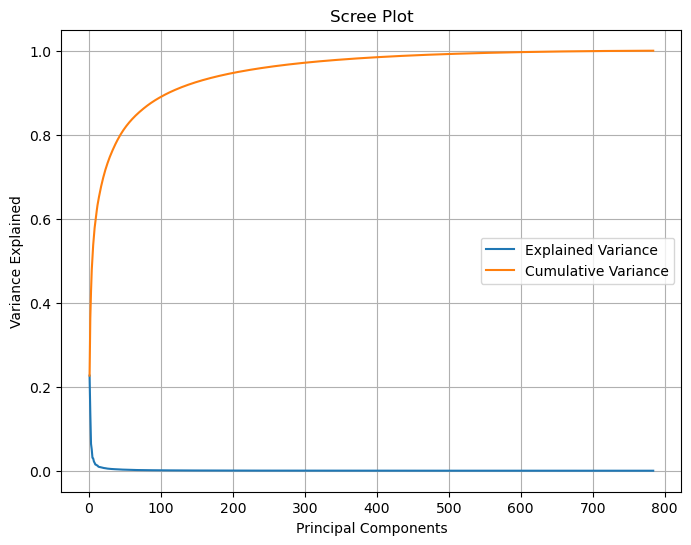

In [53]:
#PCA on whole data

scaler = StandardScaler()
image_scaled = scaler.fit_transform(train_data_X)

# Apply PCA
pca = PCA()
pca.fit(image_scaled)

# Scree plot - Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, label='Explained Variance')
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, label='Cumulative Variance')
plt.title('Scree Plot')
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.legend(loc='best')
plt.grid(True)
plt.show()

### Class distribution in 2 components space

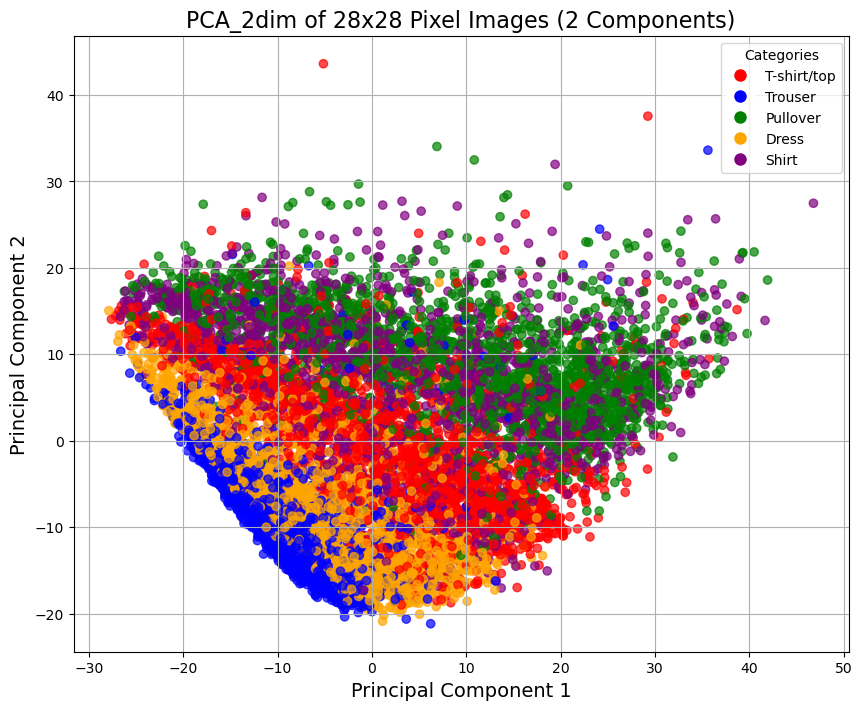

In [54]:
X_scaled = scaler.fit_transform(train_data_X)
pca_2dim = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
principal_components = pca_2dim.fit_transform(X_scaled)

# Step 6: Convert to DataFrame for easier plotting
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Step 7: Define colors for each category
categories = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
colors = ['red', 'blue', 'green', 'orange', 'purple']  # Colors corresponding to categories

# Map the categories to colors
color_map = {i: colors[i] for i in range(len(categories))}
point_colors = [color_map[int(label)] for label in train_data_y]  # Assign colors based on the labels

# Step 8: Visualize the PCA_2dim results in 2D
plt.figure(figsize=(10, 8))
plt.scatter(principal_df['PC1'], principal_df['PC2'], 
            alpha=0.7, c=point_colors)

# Labels and title
plt.title('PCA_2dim of 28x28 Pixel Images (2 Components)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)

# Create a legend
import matplotlib.lines as mlines
legend_handles = [mlines.Line2D([], [], marker='o', color='w', 
                                  label=categories[i], 
                                  markerfacecolor=colors[i], 
                                  markersize=10) for i in range(len(categories))]
plt.legend(handles=legend_handles, title='Categories')

plt.grid()
plt.show()


Example for an image with different components

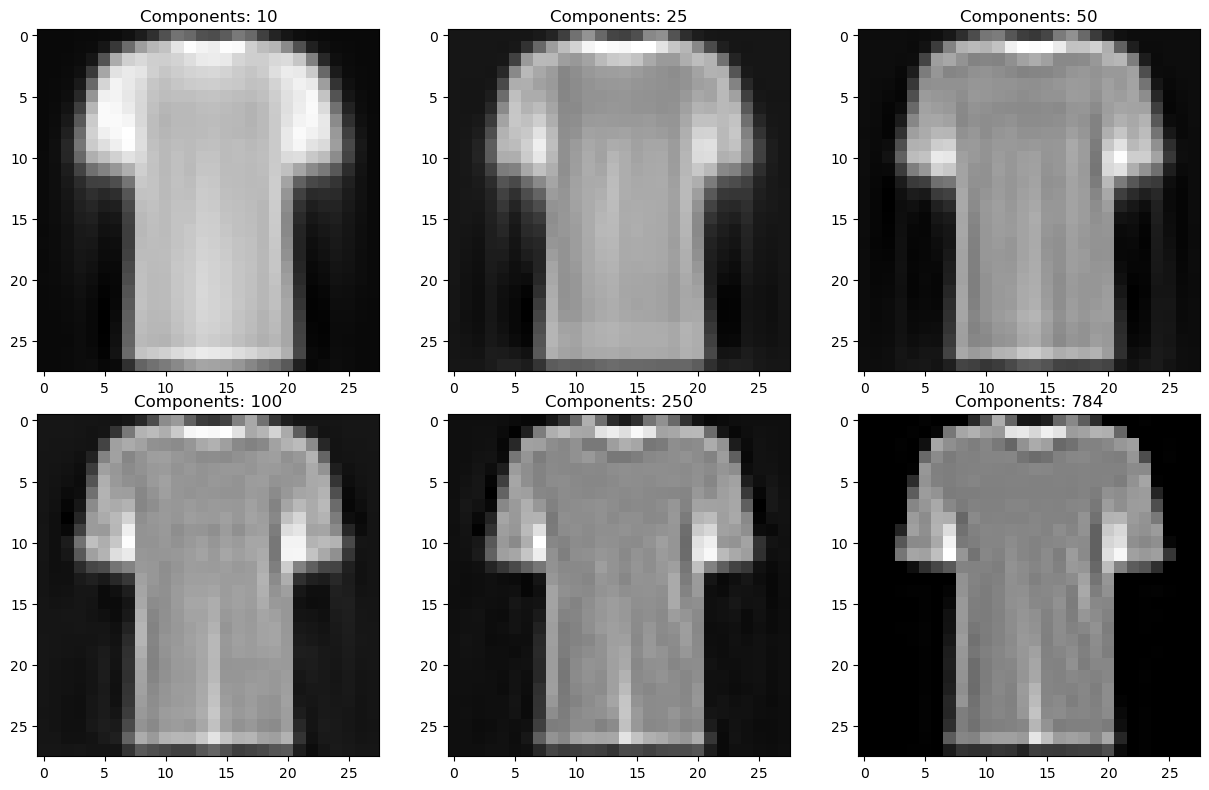

In [55]:
def plot_at_k(k):
    ipca = IncrementalPCA(n_components=k)
    image_recon = ipca.inverse_transform(ipca.fit_transform(train_data_X))[0].reshape(28,28)
    plt.imshow(image_recon,cmap = plt.cm.gray)

ks = [10, 25, 50, 100, 250, 784]
plt.figure(figsize=[15,10])

for i in range(6):
    plt.subplot(2,3,i+1)
    plot_at_k(ks[i])
    plt.title("Components: "+str(ks[i]))

plt.subplots_adjust(wspace=0.2, hspace=0.0)
plt.show()

We chose to use 100 components. The reason behind this is that we want to have a relativly low number of features but also to retain high variance. In 100 components we retain 89.01% of the original information. So we concider this as a good combination.

In [5]:
#We save our PCA for external analysis and 
 # Transforms data to 50 components
pca_100dim = PCA(n_components=100)
X_reduced_100=pca_100dim.fit_transform(train_data_X)
# Step 2: Pickle the fitted PCA model
test_X_reduced_100=pca_100dim.transform(test_data_X)

# Classification models

## 1.Manual implementations
### 1.1 Decicion tree

Our implementation:

In [60]:

class TreeNode:
    def __init__(self, data, feature_idx, feature_val, prediction_probs):
        self.data = data
        self.feature_idx = feature_idx
        self.feature_val = feature_val
        self.prediction_probs = prediction_probs
        self.left = None
        self.right = None

    def node_def(self):
        unique_values, value_counts = np.unique(self.data[:, -1], return_counts=True)
        output = ", ".join([f"{value}->{count}" for value, count in zip(unique_values, value_counts)])
        return f"LEAF | Label Counts = {output} | Pred Probs = {self.prediction_probs}"

class DecisionTreeFromScratch:
    def __init__(self, max_depth, min_leaf):
        self.max_depth = max_depth
        self.min_leaf = min_leaf
        self.tree = None

    def _entropy(self, class_probabilities):
        return sum([-p * np.log2(p) for p in class_probabilities if p > 0])

    def _class_probabilities(self, labels):
        total_count = len(labels)
        return [count / total_count for count in Counter(labels).values()]

    def _data_entropy(self, labels):
        return self._entropy(self._class_probabilities(labels))

    def _partition_entropy(self, subsets):
        total_count = sum(len(subset) for subset in subsets)
        return sum(self._data_entropy(subset) * (len(subset) / total_count) for subset in subsets)

    def _split_indices(self, data, feature_index, feature_val):
        mask = data[:, feature_index] < feature_val
        return np.where(mask)[0], np.where(~mask)[0]

    def _find_best_split(self, data):
        min_part_entropy = float('inf')
        best_split = None
        n_features = data.shape[1] - 1  # Exclude label column

        for idx in range(n_features):
            feature_vals = np.percentile(data[:, idx], q=np.linspace(0, 100, num=20))  # Optimize thresholds
            for feature_val in feature_vals:
                left_idx, right_idx = self._split_indices(data, idx, feature_val)
                if len(left_idx) == 0 or len(right_idx) == 0:  # Skip invalid splits
                    continue
                part_entropy = self._partition_entropy([data[left_idx, -1], data[right_idx, -1]])
                if part_entropy < min_part_entropy:
                    min_part_entropy = part_entropy
                    best_split = (left_idx, right_idx, idx, feature_val, min_part_entropy)

        return best_split if best_split else (None, None, None, None, None)

    def _find_label_probs(self, labels):
        total_labels = len(labels)
        label_probabilities = np.zeros(len(self.labels_in_train), dtype=float)
        for i, label in enumerate(self.labels_in_train):
            count = np.sum(labels == label)
            label_probabilities[i] = count / total_labels
        return label_probabilities

    def _create_tree(self, data, indices, current_depth):
        if current_depth >= self.max_depth or len(indices) < self.min_leaf:
            return None

        split = self._find_best_split(data[indices])
        if not split:
            return None

        left_idx, right_idx, split_feature_idx, split_feature_val, _ = split
        left_data_indices = indices[left_idx]
        right_data_indices = indices[right_idx]
        label_probabilities = self._find_label_probs(data[indices, -1])

        node = TreeNode(data[indices], split_feature_idx, split_feature_val, label_probabilities)
        if len(left_data_indices) < self.min_leaf or len(right_data_indices) < self.min_leaf:
            return node

        current_depth += 1
        node.left = self._create_tree(data, left_data_indices, current_depth)
        node.right = self._create_tree(data, right_data_indices, current_depth)
        return node

    def _predict_one_sample(self, X):
        node = self.tree
        while node.left or node.right:
            if X[node.feature_idx] < node.feature_val:
                node = node.left
            else:
                node = node.right
        return node.prediction_probs

    def fit(self, X_train, Y_train):
        self.labels_in_train = np.unique(Y_train)
        train_data = np.concatenate((X_train, np.reshape(Y_train, (-1, 1))), axis=1)
        indices = np.arange(len(train_data))
        self.tree = self._create_tree(data=train_data, indices=indices, current_depth=0)

    def predict_proba(self, X_set):
        return np.apply_along_axis(self._predict_one_sample, 1, X_set)

    def predict(self, X_set):
        pred_probs = self.predict_proba(X_set)
        return np.argmax(pred_probs, axis=1)

    def evaluate_model(self, X_val, y_val, labels):
        predictions = self.predict(X_val)
        accuracy = accuracy_score(y_val, predictions)
        recall_per_class = recall_score(y_val, predictions, average=None, labels=labels)
        conf_matrix = confusion_matrix(y_val, predictions, labels=labels)

        print("Overall Accuracy:", accuracy)
        print("Recall per Class:")
        for label, recall in zip(labels, recall_per_class):
            print(f"Class {label}: {recall:.4f}")
        print("\nConfusion Matrix:\n", conf_matrix)

        return accuracy, recall_per_class, conf_matrix

# Main Code: Data Loading and Cross-Validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
fold_recalls = []
fold_conf_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(X_reduced_100)):
    print(f"\nTraining Fold {fold + 1}")

    X_train, X_val = X_reduced_100[train_index], X_reduced_100[val_index]
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]

    house_plant = DecisionTreeFromScratch(max_depth=10, min_leaf=10)
    house_plant.fit(X_train, y_train)
    labels = np.unique(y_train)

    accuracy, recall_per_class, conf_matrix = house_plant.evaluate_model(X_val, y_val, labels)
    fold_accuracies.append(accuracy)
    fold_recalls.append(recall_per_class)
    fold_conf_matrices.append(conf_matrix)
    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")

# Print Final Results
print("\nFinal Cross-Validation Results")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}")
print("Mean Recall per Class:", np.mean(fold_recalls, axis=0))

# Print Final Results
print("\nFinal Cross-Validation Results")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.2f}")
print("Mean Recall per Class:", np.mean(fold_recalls, axis=0))


Training Fold 1
Overall Accuracy: 0.7685
Recall per Class:
Class 0: 0.7398
Class 1: 0.9208
Class 2: 0.7629
Class 3: 0.8593
Class 4: 0.5738

Confusion Matrix:
 [[307   9  11  17  71]
 [  5 349   4  17   4]
 [  5   0 296  14  73]
 [ 21   7   7 348  22]
 [ 74   5  70  27 237]]
Fold 1 Accuracy: 0.7685

Training Fold 2
Overall Accuracy: 0.752
Recall per Class:
Class 0: 0.6583
Class 1: 0.9466
Class 2: 0.7835
Class 3: 0.8131
Class 4: 0.5541

Confusion Matrix:
 [[262   6   8  33  89]
 [  2 372   5  10   4]
 [ 13   0 333  17  62]
 [ 29  14   6 322  25]
 [ 65   4  75  29 215]]
Fold 2 Accuracy: 0.7520

Training Fold 3
Overall Accuracy: 0.7535
Recall per Class:
Class 0: 0.6867
Class 1: 0.9322
Class 2: 0.8443
Class 3: 0.8693
Class 4: 0.4715

Confusion Matrix:
 [[274  11  14  37  63]
 [  6 371   4  16   1]
 [  3   1 309  13  40]
 [ 19  10  11 346  12]
 [ 88   1 101  42 207]]
Fold 3 Accuracy: 0.7535

Training Fold 4
Overall Accuracy: 0.773
Recall per Class:
Class 0: 0.7567
Class 1: 0.8744
Class 2: 0

### 1.2 Feed-forward neural network

Our implementation:

In [14]:
#define neural network layer
class Layer():
    def __init__(self, n_num, input_dim):
        self.weights = self.initialize_parameters(n_num, input_dim)
        self.gamma = np.ones((n_num, 1))  # Scaling factor
        self.beta = np.zeros((n_num, 1)) 

    def initialize_parameters(self, n_num, input_dim):
        """Initialize parameters with He initialization method"""
        
        parameters = {}
        parameters["W"] = np.random.randn(n_num, input_dim) * np.sqrt(2/input_dim)
        parameters["b"] = np.zeros((n_num, 1))

        return parameters
    
class Adam_optimizer():
    def __init__(self, learning_rate, beta1, beta2, epsilon):
        self.momentum_w = {}
        self.momentum_b = {}
        self.rms_w = {}
        self.rms_b = {}
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.learning_rate = learning_rate
        self.t = 0  # Time step for bias correction


    def update_parameters(self, parameters, gradients, epoch):#(self, t, l_num, b, dw, db):
        ## Compute decayed learning rate
        
        ## dw, db are from current minibatch
        ## momentum beta 1
        # *** weights *** #
        self.t += 1
        
        # Update parameters for each layer
        for l_num, l in enumerate(parameters, start=1):
            #print(l_num)
            #print(gradients["dW" + str(l_num)].shape, )
            # Initialize caches if not already present
            if l_num not in self.momentum_w:
                self.momentum_w[l_num] = np.zeros_like(parameters[l_num-1][0].weights['W'])
                self.momentum_b[l_num] = np.zeros_like(parameters[l_num-1][0].weights['b'])
                self.rms_w[l_num] = np.zeros_like(parameters[l_num-1][0].weights['W'])
                self.rms_b[l_num] = np.zeros_like(parameters[l_num-1][0].weights['b'])
            # Momentum updates
            self.momentum_w[l_num] = self.beta1 * self.momentum_w[l_num] + (1 - self.beta1) * gradients["dW" + str(l_num)]
            self.momentum_b[l_num] = self.beta1 * self.momentum_b[l_num] + (1 - self.beta1) * gradients["db" + str(l_num)]
            
            # RMS updates
            self.rms_w[l_num] = self.beta2 * self.rms_w[l_num] + (1 - self.beta2) * (gradients["dW" + str(l_num)]**2)
            self.rms_b[l_num] = self.beta2 * self.rms_b[l_num] + (1 - self.beta2) * (gradients["db" + str(l_num)]**2)
            
            # Bias correction
            momentum_w_corr = self.momentum_w[l_num] / (1 - self.beta1**self.t)
            momentum_b_corr = self.momentum_b[l_num] / (1 - self.beta1**self.t)
            rms_w_corr = self.rms_w[l_num] / (1 - self.beta2**self.t)
            rms_b_corr = self.rms_b[l_num] / (1 - self.beta2**self.t)

            # Update weights and biases
            l[0].weights['W'] -= self.learning_rate* (momentum_w_corr / (np.sqrt(rms_w_corr) + self.epsilon))
            l[0].weights['b'] -= self.learning_rate * (momentum_b_corr / (np.sqrt(rms_b_corr) + self.epsilon))
            
        return parameters

class Mini_Batch_GD_optimizer():
    def __init__(self, learning_rate, decay_rate=0.01):
        #gradients=self.find_gradients(parameters, forward_vars, Y)
        #self.update_parameters(parameters, gradients, learning_rate)
        self.learning_rate=learning_rate
        self.decay_rate=decay_rate
    
    def update_parameters(self, parameters, gradients, epoch):
        decayed_learning_rate = self.learning_rate * np.exp(-self.decay_rate * epoch)
        l_num=0
        for l in parameters:
            l[0].weights['W'] -= decayed_learning_rate * gradients["dW"+str(l_num)]
            l[0].weights['b'] -= decayed_learning_rate * gradients["db"+str(l_num)]
            l_num+=1
        return parameters
    
#define fnn    
class FFNN():
    def __init__(self):
        self.layers=[]
        self.optimizer=None
        self.metrics={}
        #self.weights = []
    
    def add_layer(self, n_num, input_dim=None, activation="relu"):
        if input_dim is None:
            if len(self.layers) == 0:
                raise ValueError("Input dimension must be provided for the first layer.")
            input_dim = len(self.layers[-1][0].weights['W'])
        new_layer = Layer(n_num, input_dim)
        self.layers.append([new_layer, activation])
    def compile(self, optimizer='adam', learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, metrics=['accuracy']):
        if optimizer=='adam':
            self.optimizer=Adam_optimizer(learning_rate, beta1, beta2, epsilon )
        elif optimizer=='mini':
            self.optimizer=Mini_Batch_GD_optimizer(learning_rate)
        for m in metrics: self.metrics.update({m : []})
        
        
    def fit(self, X_train, Y_train, batch_size, epochs=0):

        self.minibatch_size = batch_size
        temp_weights=self.layers.copy()
        for i in range(epochs):
            for batch_idx in range(0, int(X_train.shape[0] / batch_size)):
                # Mini Batch Samples
                if batch_idx == int(X_train.shape[1] / batch_size):
                    X = X_train[:, batch_idx*batch_size:]
                    Y = Y_train[:, batch_idx*batch_size:]
                else:
                    X = X_train[:, batch_idx*batch_size: (batch_idx+1)*batch_size]
                    Y = Y_train[:, batch_idx*batch_size: (batch_idx+1)*batch_size]
                
                output_history=self.feed_forward(temp_weights, X)
                prediction= output_history["A"+str(len(temp_weights))]
                y_pred = np.argmax(prediction, axis=0) 
                #self.get_stats(y_pred, Y)
                
                gradients = self.backward_prop(temp_weights, output_history, Y)
                temp_weights = self.optimizer.update_parameters(temp_weights, gradients, epoch=i)
        self.layers=temp_weights
        

    
    def feed_forward(self, temp_weights, I):
        forward_vars = {"A0": I}
        running_mean, running_var = {}, {}
        
        #return forward_vars #{k: v for k, v in forward_vars.items() if k.startswith("A")}
        for l_num in range(1, len(temp_weights) + 1):
            layer = temp_weights[l_num - 1]
            forward_vars["Z"+str(l_num)] = np.dot(layer[0].weights['W'], forward_vars["A" + str(l_num - 1)]) + layer[0].weights['b']

            # Batch Normalization
            mean = np.mean(forward_vars["Z"+str(l_num)], axis=1, keepdims=True)
            var = np.var(forward_vars["Z"+str(l_num)], axis=1, keepdims=True)
            Z_norm = (forward_vars["Z"+str(l_num)] - mean) / np.sqrt(var + 1e-8)
            Z_bn = layer[0].gamma * Z_norm + layer[0].beta

            # Save running mean and variance for inference
            running_mean[l_num] = mean
            running_var[l_num] = var

            # Activation
            forward_vars["Z" + str(l_num)] = Z_bn
            forward_vars["A" + str(l_num)] = self._activate(Z_bn, layer[1])
        #print(forward_vars)
        return forward_vars
    
    def backward_prop(self, parameters, forward_vars, Y):
        gradients = {}
        l_num = len(parameters)

        for l_num in range(len(parameters), 0, -1):
            m = forward_vars["A" + str(l_num - 1)].shape[1]
            layer = parameters[l_num - 1]

            if layer[1] == 'sigmoid':
                gradients["dA" + str(l_num)] = -np.divide(Y, forward_vars["A" + str(l_num)]) + np.divide((1 - Y), (1 - forward_vars["A" + str(l_num)]))
                gradients["dZ" + str(l_num)] = gradients["dA" + str(l_num)] * forward_vars["A" + str(l_num)] * (1 - forward_vars["A" + str(l_num)])
            # other activations
            elif layer[1] == 'relu':
                relu_derivative = forward_vars["A"+str(l_num)] > 0
                gradients["dZ"+str(l_num)] = np.multiply(gradients["dA"+str(l_num)], relu_derivative)
            elif layer[1] == "leaky_relu":
                leaky_relu_derivative = np.where(forward_vars["A" + str(l_num)] > 0, 1, 0.01)
                gradients["dZ" + str(l_num)] = np.multiply(gradients["dA" + str(l_num)], leaky_relu_derivative)
            elif layer[1] == 'softmax':
                gradients["dZ"+str(l_num)] = forward_vars["A"+str(l_num)] - Y 
            

            # Batch Normalization Backpropagation
            dZ = gradients["dZ" + str(l_num)]
            mean = np.mean(forward_vars["Z" + str(l_num)], axis=1, keepdims=True)
            var = np.var(forward_vars["Z" + str(l_num)], axis=1, keepdims=True)
            Z_norm = (forward_vars["Z" + str(l_num)] - mean) / np.sqrt(var + 1e-8)

            gradients["dgamma" + str(l_num)] = np.sum(dZ * Z_norm, axis=1, keepdims=True)
            gradients["dbeta" + str(l_num)] = np.sum(dZ, axis=1, keepdims=True)
            dZ_norm = dZ * layer[0].gamma

            dvar = np.sum(dZ_norm * (forward_vars["Z" + str(l_num)] - mean) * -0.5 * (var + 1e-8) ** (-1.5), axis=1, keepdims=True)
            dmean = np.sum(dZ_norm * -1 / np.sqrt(var + 1e-8), axis=1, keepdims=True) + dvar * np.mean(-2 * (forward_vars["Z" + str(l_num)] - mean), axis=1, keepdims=True)
            gradients["dZ" + str(l_num)] = dZ_norm / np.sqrt(var + 1e-8) + dvar * 2 * (forward_vars["Z" + str(l_num)] - mean) / m + dmean / m

            # Weights and biases
            
            gradients["dW" + str(l_num)] = (1 / m) * np.dot(gradients["dZ" + str(l_num)], forward_vars["A" + str(l_num - 1)].T)
            gradients["db" + str(l_num)] = (1 / m) * np.sum(gradients["dZ" + str(l_num)], axis=1, keepdims=True)
            gradients["dA" + str(l_num - 1)] = np.dot(layer[0].weights['W'].T, gradients["dZ" + str(l_num)])
        #print(gradients)
        return gradients
    
    def predict(self, X):
            """Predict labels for given data X"""
            #print(self.layers[0][0].weights['W'])
            forward_vars = self.feed_forward(self.layers, X)
            
            L = len(self.layers)
            #print(forward_vars["A"+str(L)])
            return forward_vars["A"+str(L)]
    
    def _activate(self, I, activation):
        
        if activation=='relu':
            result=np.maximum(0, I)
        elif activation == 'leaky_relu':
            result = np.where(I > 0, I, 0* I) 
        elif activation=='softmax':
            T = np.exp(I - np.max(I, axis=0, keepdims=True))
            T_sum = np.sum(T, axis=0, keepdims=True)
            result = np.divide(T, T_sum)
        elif activation=='sigmoid':
            result = 1 / (1 + np.exp(-I))
        else:
            print("Error")
        return result
    
    def get_stats(self, Y_hat, Y, num_classes=5):
        """
        Log Loss is applied
        """
        

        #np.eye(num_classes)[Y_hat]
        
        # Count correct predictions
        accuracy = accuracy_score(Y, Y_hat)
        
        # Calculate accuracy
        # Calculate recall for each class
        micro_recall = recall_score(Y, Y_hat, average='micro')


        # Macro-average recall
        macro_recall = recall_score(Y, Y_hat, average='macro')

        # Weighted-average recall
        weighted_recall = recall_score(Y, Y_hat, average='weighted')
        
        if 'loss' in self.metrics.keys():
            self.metrics['loss'].append(-np.sum(Y * np.log(Y_hat + 10**-100)))
        if 'accuracy' in self.metrics.keys():
            self.metrics['accuracy'].append(accuracy)
        if 'micro_recall' in self.metrics.keys():
            self.metrics['micro_recall'].append(micro_recall)
        if 'macro_recall' in self.metrics.keys():
            self.metrics['macro_recall'].append(macro_recall)
        if 'weighted_recall' in self.metrics.keys():
            self.metrics['weighted_recall'].append(weighted_recall)
 

In [15]:
def create_multiclass_model_from_scratch_raw(input_dim, num_classes):
    model = FFNN()
    model.add_layer(256, input_dim=input_dim, activation='leaky_relu') # First hidden layer
    model.add_layer(128, activation='leaky_relu') # First hidden layer
    model.add_layer(64, activation='leaky_relu')  # Second hidden layer
    model.add_layer(32, activation='leaky_relu')  # Third hidden layer
    model.add_layer(num_classes, activation='softmax')  # Output layer for multi-class classification
  
    # Compile the model
    model.compile(optimizer='adam',learning_rate=0.001,
                 #loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if using one-hot encoding
                 #metrics=['accuracy', 'loss', 'micro_recall']
                 )
    return model
def create_multiclass_model_from_scratch_pca(input_dim, num_classes):
    model_100 = FFNN()
    model_100.add_layer(128, input_dim=input_dim, activation='leaky_relu') # First hidden layer
    model_100.add_layer(64, activation='leaky_relu')  # Second hidden layer
    model_100.add_layer(32, activation='leaky_relu')  # Third hidden layer
    model_100.add_layer(num_classes, activation='softmax')  # Output layer for multi-class classification
  
    # Compile the model
    model_100.compile(optimizer='adam',learning_rate=0.001,
                 #loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if using one-hot encoding
                 #metrics=['accuracy', 'loss', 'micro_recall']
    )
   
    return model_100

5-fold cross-validation with raw data

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []
def one_hot_encode(Y, num_classes):
    return np.eye(num_classes)[Y]

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = train_data_X[train_index].T, train_data_X[val_index].T
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    y_train = one_hot_encode(y_train, 5).T
   
    # Create a new instance of the model
    model = create_multiclass_model_from_scratch_raw(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
    #print(X_val.shape, X_train.shape)
    # Train the model
    model.fit(X_train, y_train, epochs=100, batch_size=32)
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=0)  # Get the predicted class for each sample

    # Calculate accuracy for the current fold
    
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")

Training fold 1
Fold 1 Accuracy: 0.8075
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.81      0.74      0.77       415
           1       1.00      0.96      0.98       379
           2       0.74      0.82      0.78       388
           3       0.90      0.89      0.89       405
           4       0.62      0.65      0.63       413

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000

Confusion Matrix for Fold 1:
 [[308   0  22  13  72]
 [  2 362   4   7   4]
 [  1   0 317   7  63]
 [  9   0  13 361  22]
 [ 61   1  70  14 267]]
Training fold 2
Fold 2 Accuracy: 0.8195
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.77      0.76      0.77       398
           1       0.98      0.97      0.97       393
           2       0.84      0.85      0.84       42

5-fold cross-validation with 100 components

In [13]:
kf = KFold(n_splits=5, shuffle=True)
fold_accuracies_pca = []
all_classification_reports_pca = []
all_confusion_matrices_pca = []
def one_hot_encode(Y, num_classes):
    return np.eye(num_classes)[Y]
    # Split the data into training and validation sets for the current fold
    
for fold, (train_index, val_index) in enumerate(kf.split(X_reduced_100)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = X_reduced_100[train_index].T, X_reduced_100[val_index].T
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    y_train = one_hot_encode(y_train, 5).T
    # Create a new instance of the model
    model = create_multiclass_model_from_scratch_pca(input_dim=X_reduced_100.shape[1], num_classes=len(np.unique(train_data_y)))
    #print(X_val.shape, X_train.shape)
    
    # Train the model
    model.fit(X_train, y_train, epochs=100, batch_size=32)
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=0)  # Get the predicted class for each sample
    #print(y_val_pred.shape)
    #print(y_val.shape)
    # Calculate accuracy for the current fold
    accuracy_pca = accuracy_score(y_val, y_val_pred)
    fold_accuracies_pca.append(accuracy_pca)
    
    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports_pca.append(class_report)
    all_confusion_matrices_pca.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy_pca:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy_pca = np.mean(fold_accuracies_pca)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy_pca:.4f}")

Training fold 1
Fold 1 Accuracy: 0.5840
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.56      0.48      0.52       395
           1       0.77      0.88      0.82       385
           2       0.49      0.46      0.48       401
           3       0.67      0.67      0.67       402
           4       0.41      0.44      0.43       417

    accuracy                           0.58      2000
   macro avg       0.58      0.59      0.58      2000
weighted avg       0.58      0.58      0.58      2000

Confusion Matrix for Fold 1:
 [[188  18  69  63  57]
 [ 15 340   3  18   9]
 [ 30  17 186   6 162]
 [ 44  39  18 271  30]
 [ 58  26 105  45 183]]
Training fold 2
Fold 2 Accuracy: 0.5995
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.58      0.50      0.54       411
           1       0.71      0.78      0.74       390
           2       0.55      0.62      0.58       37

## 2. Reference  implementations
### 2.1 Decicion tree

Grid search with raw data

In [61]:
#Grid search for best parameters
param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [ 10, 15, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize the Decision Tree model
dt = tree.DecisionTreeClassifier()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(train_data_X, train_data_y)

# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated accuracy score:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validated accuracy score: 0.8022


Grid search with 100 components data

In [63]:
#Grid search for best parameters
param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': [None]
}

# Initialize the Decision Tree model
dt = tree.DecisionTreeClassifier()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_reduced_100, train_data_y)

# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated accuracy score:", grid_search.best_score_)

Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validated accuracy score: 0.7631


## 2.2 Feed-forward neural network

Model building

In [125]:
def create_multiclass_model_raw(input_dim, num_classes):
    model = Sequential()
    model.add(Dense(256, input_dim=input_dim, activation='leaky_relu'))
    model.add(Dense(128, activation='leaky_relu'))  # First hidden layer
    model.add(Dense(64, activation='leaky_relu'))  # Second hidden layer
    model.add(Dense(32, activation='leaky_relu'))  # Third hidden layer
    model.add(Dense(num_classes, activation='softmax'))  # Output layer for multi-class classification
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if using one-hot encoding
                  metrics=['accuracy'])
    return model

def create_multiclass_model_pca(input_dim, num_classes):
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='leaky_relu'))  # First hidden layer
    model.add(Dense(64, activation='leaky_relu'))  # Second hidden layer
    model.add(Dense(32, activation='leaky_relu'))  # Third hidden layer
    model.add(Dense(num_classes, activation='softmax'))  # Output layer for multi-class classification
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if using one-hot encoding
                  metrics=['accuracy'])
    return model

5-fold cross-validation with raw data

In [ ]:

# Set up 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = train_data_X[train_index], train_data_X[val_index]
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    
    # Create a new instance of the model
    model = create_multiclass_model_raw(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
    
    # Train the model
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Get the predicted class for each sample

    # Calculate accuracy for the current fold
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")

Training fold 1


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Fold 1 Accuracy: 0.8440
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.78      0.89      0.83       415
           1       0.97      0.97      0.97       379
           2       0.74      0.95      0.83       388
           3       0.92      0.90      0.91       405
           4       0.86      0.54      0.66       413

    accuracy                           0.84      2000
   macro avg       0.85      0.85      0.84      2000
weighted avg       0.85      0.84      0.84      2000

Confusion Matrix for Fold 1:
 [[369   1  19   7  19]
 [  2 367   3   6   1]
 [  5   1 367   6   9]
 [ 14   6  15 364   6]
 [ 83   2  93  14 221]]
Training fold 2


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Fold 2 Accuracy: 0.8520
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.77      0.85      0.81       398
           1       0.97      0.99      0.98       393
           2       0.79      0.95      0.86       425
           3       0.94      0.87      0.90       396
           4       0.81      0.59      0.68       388

    accuracy                           0.85      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion Matrix for Fold 2:
 [[339   3  18  11  27]
 [  1 390   1   1   0]
 [  4   0 403   1  17]
 [ 22   9  11 344  10]
 [ 74   2  76   8 228]]
Training fold 3


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Fold 3 Accuracy: 0.8485
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.84      0.77      0.81       399
           1       0.99      0.97      0.98       398
           2       0.81      0.89      0.85       366
           3       0.82      0.96      0.88       398
           4       0.78      0.67      0.72       439

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion Matrix for Fold 3:
 [[308   1  12  32  46]
 [  1 386   0  10   1]
 [  2   0 325   9  30]
 [  3   0   6 382   7]
 [ 52   2  56  33 296]]
Training fold 4


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 4 Accuracy: 0.8760
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.84      0.80      0.82       411
           1       0.99      0.98      0.99       414
           2       0.92      0.87      0.89       406
           3       0.90      0.95      0.92       396
           4       0.72      0.78      0.75       373

    accuracy                           0.88      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.88      0.88      0.88      2000

Confusion Matrix for Fold 4:
 [[329   0   1  21  60]
 [  0 406   0   7   1]
 [ 10   0 352   5  39]
 [  7   3   1 375  10]
 [ 47   1  28   7 290]]
Training fold 5


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Fold 5 Accuracy: 0.8710
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       410
           1       0.99      0.96      0.97       363
           2       0.85      0.91      0.88       416
           3       0.87      0.93      0.90       410
           4       0.83      0.67      0.74       401

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion Matrix for Fold 5:
 [[362   2   2  17  27]
 [  3 350   0  10   0]
 [ 10   2 377   8  19]
 [  7   1   9 383  10]
 [ 58   0  53  20 270]]

Average Accuracy across 5 folds: 0.8583


5-fold cross-validation with 100 components

In [ ]:
# pca
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(X_reduced_100)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = X_reduced_100[train_index], X_reduced_100[val_index]
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    
    # Create a new instance of the model
    model = create_multiclass_model_pca(input_dim=X_reduced_100.shape[1], num_classes=len(np.unique(train_data_y)))
    
    # Train the model
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Get the predicted class for each sample

    # Calculate accuracy for the current fold
    accuracy_pca = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy_pca)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy_pca:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy_pca = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy_pca:.4f}")

Training fold 1


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Fold 1 Accuracy: 0.8735
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86       415
           1       0.99      0.97      0.98       379
           2       0.85      0.87      0.86       388
           3       0.94      0.91      0.92       405
           4       0.74      0.79      0.76       413

    accuracy                           0.87      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.87      0.87      2000

Confusion Matrix for Fold 1:
 [[349   0   7   7  52]
 [  0 367   4   5   3]
 [  1   1 339   3  44]
 [  8   3   9 367  18]
 [ 40   1  38   9 325]]
Training fold 2


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Fold 2 Accuracy: 0.8735
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.81      0.82      0.82       398
           1       0.99      0.99      0.99       393
           2       0.91      0.87      0.89       425
           3       0.93      0.93      0.93       396
           4       0.73      0.76      0.75       388

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion Matrix for Fold 2:
 [[326   0   8  10  54]
 [  2 388   0   3   0]
 [  9   1 369   3  43]
 [ 14   2   1 369  10]
 [ 50   2  28  13 295]]
Training fold 3


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Fold 3 Accuracy: 0.8550
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.80      0.81      0.80       399
           1       0.97      0.98      0.98       398
           2       0.85      0.88      0.86       366
           3       0.92      0.88      0.90       398
           4       0.74      0.74      0.74       439

    accuracy                           0.85      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.85      0.86      2000

Confusion Matrix for Fold 3:
 [[322   0   7   9  61]
 [  3 390   0   5   0]
 [  5   1 321   4  35]
 [ 14   7   8 352  17]
 [ 59   2  41  12 325]]
Training fold 4


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Fold 4 Accuracy: 0.8705
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.90      0.77      0.83       411
           1       0.99      0.97      0.98       414
           2       0.89      0.89      0.89       406
           3       0.89      0.92      0.91       396
           4       0.69      0.80      0.74       373

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.88      0.87      0.87      2000

Confusion Matrix for Fold 4:
 [[315   0   6  17  73]
 [  2 402   1   7   2]
 [  2   0 361   5  38]
 [  7   4   2 365  18]
 [ 24   1  35  15 298]]
Training fold 5


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Fold 5 Accuracy: 0.8655
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       410
           1       0.98      0.97      0.97       363
           2       0.85      0.91      0.87       416
           3       0.90      0.93      0.92       410
           4       0.78      0.68      0.72       401

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.86      0.87      0.86      2000

Confusion Matrix for Fold 5:
 [[351   2   5   9  43]
 [  2 351   1   8   1]
 [  9   0 377   8  22]
 [  9   4   6 381  10]
 [ 56   1  57  16 271]]

Average Accuracy across 5 folds: 0.8676


## 2.3 CNN

In [ ]:
def create_cnn_model(input_shape, num_classes):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='leaky_relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='leaky_relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(256, activation='leaky_relu'))
    model.add(Dense(128, activation='leaky_relu'))
    model.add(Dense(32, activation='leaky_relu'))
    model.add(Dense(num_classes, activation='softmax'))  # Softmax for multi-class classification
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = train_data_X[train_index].reshape(-1, 28, 28,1), train_data_X[val_index].reshape(-1, 28, 28,1)
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    #print(X_train[0])
    
    # Create a new instance of the CNN model
    model = create_cnn_model(input_shape=train_data_X.reshape(-1, 28, 28, 1).shape[1:], num_classes=len(np.unique(train_data_y)))
    
    # Train the model
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Convert probabilities to class predictions
    
    # Calculate accuracy for the current fold
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")

Training fold 1
Fold 1 Accuracy: 0.8775
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.86      0.83      0.84       415
           1       0.97      0.98      0.97       379
           2       0.92      0.88      0.90       388
           3       0.95      0.89      0.92       405
           4       0.73      0.82      0.77       413

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion Matrix for Fold 1:
 [[344   1   8   4  58]
 [  0 371   1   2   5]
 [  4   0 340   5  39]
 [  8  10   1 360  26]
 [ 46   1  19   7 340]]
Training fold 2
Fold 2 Accuracy: 0.8695
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80       398
           1       1.00      0.97      0.98       393
           2       0.90      0.91      0.91       42

# Final tests

Evaluate performance on fashion_test.npy. 

In [131]:
build_in_dt=tree.DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=10)
dt_from_scratch=DecisionTreeFromScratch(max_depth=10, min_leaf=10)
build_in_fnn=create_multiclass_model_raw(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
fnn_from_scratch=create_multiclass_model_from_scratch_raw(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
build_in_cnn=create_cnn_model(input_shape=train_data_X.reshape(-1, 28, 28, 1).shape[1:], num_classes=len(np.unique(train_data_y)))


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Test the tree models
### Skitlern model

Accuracy: 0.39
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.69      0.71      1036
           1       0.00      0.08      0.01        53
           2       0.22      0.30      0.25       716
           3       0.43      0.67      0.53       643
           4       0.58      0.23      0.33      2552

    accuracy                           0.39      5000
   macro avg       0.39      0.39      0.36      5000
weighted avg       0.53      0.39      0.42      5000

Confusion Matrix:
[[718  13  25  74 206]
 [ 33   4   2   4  10]
 [ 28 366 217  13  92]
 [ 32  10  61 432 108]
 [189 607 695 477 584]]


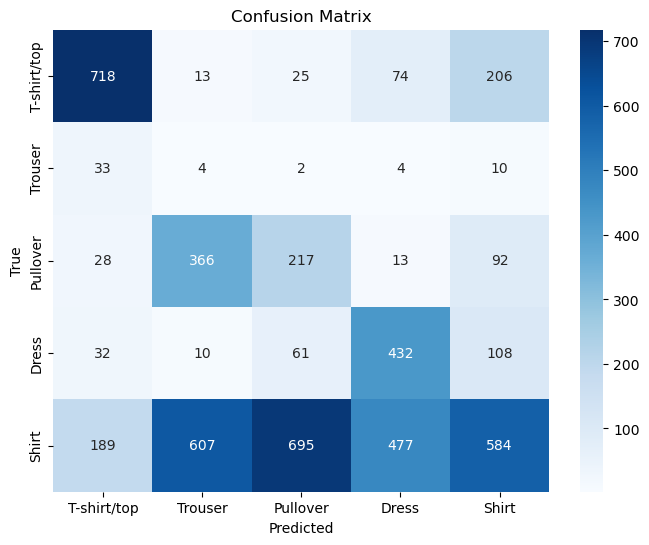

In [130]:
build_in_dt.fit(X_reduced_100,train_data_y)
predicted_y=build_in_dt.predict(test_X_reduced_100)

# Evaluate accuracy
accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix1 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix1)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix1, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Our implemntation

Accuracy: 0.69
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.64      0.60       908
           1       0.83      0.98      0.90       849
           2       0.84      0.61      0.71      1394
           3       0.70      0.72      0.71       971
           4       0.49      0.56      0.53       878

    accuracy                           0.69      5000
   macro avg       0.69      0.70      0.69      5000
weighted avg       0.70      0.69      0.69      5000

Confusion Matrix:
[[577   9  12 146 164]
 [  5 829   3   6   6]
 [189  14 845  82 264]
 [ 47 135  20 697  72]
 [182  13 120  69 494]]


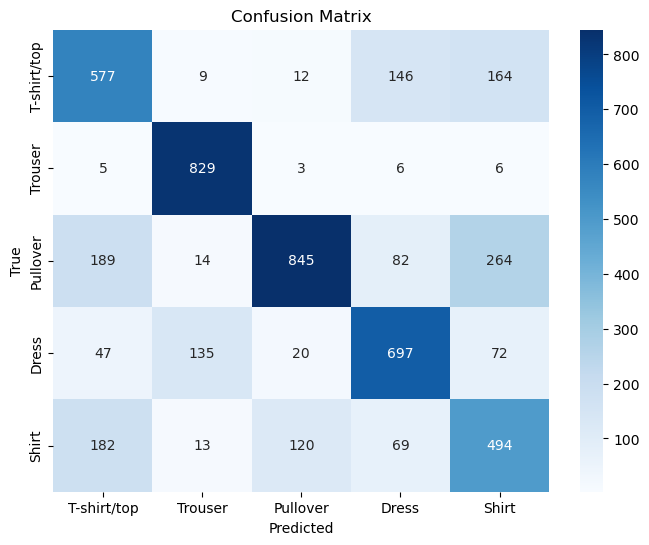

In [140]:
dt_from_scratch.fit(train_data_X,train_data_y)
predicted_y=dt_from_scratch.predict(test_data_X)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix2 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix2)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix2, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Test the Feed-forward neural networks models
### Tensorflow implementation

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9915 - loss: 0.0268
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9918 - loss: 0.0233
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9737 - loss: 0.0930
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9938 - loss: 0.0151
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9905 - loss: 0.0253
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9981 - loss: 0.0075
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9781 - loss: 0.0804
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9930 - loss: 0.0178
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9978 - loss: 0.0094
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9865 - loss: 0.0393
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.85
Classification Report:
              precision    recall  f1-score   support

     

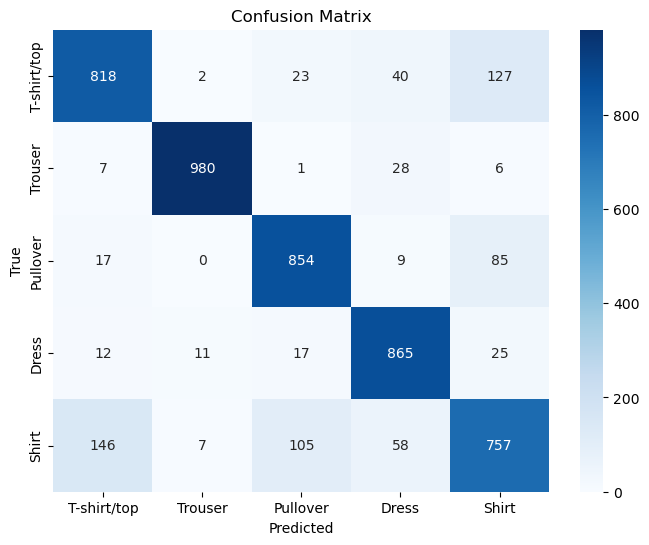

In [138]:
build_in_fnn.fit(train_data_X, train_data_y, epochs=10, batch_size=32, verbose=1)
predicted_y=np.argmax(build_in_fnn.predict(test_data_X), axis=1)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix3 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix3)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix3, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Our implemntation

Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.78      0.76       960
           1       0.95      0.97      0.96       974
           2       0.81      0.80      0.81      1018
           3       0.86      0.88      0.87       977
           4       0.68      0.64      0.66      1071

    accuracy                           0.81      5000
   macro avg       0.81      0.81      0.81      5000
weighted avg       0.81      0.81      0.81      5000

Confusion Matrix:
[[747   8  14  46 145]
 [  3 949   1  18   3]
 [ 27  13 815  18 145]
 [ 51  26  18 857  25]
 [172   4 152  61 682]]


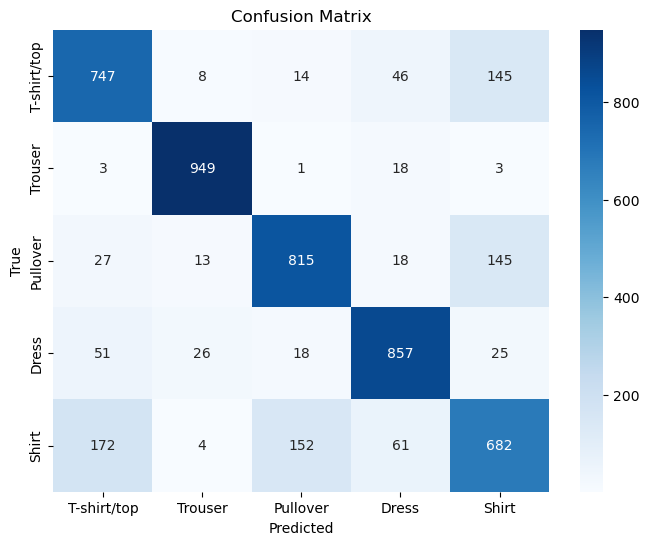

In [145]:
y_train = one_hot_encode(train_data_y, 5).T
fnn_from_scratch.fit(train_data_X.T, y_train, epochs=100, batch_size=32)
predicted_y=np.argmax(fnn_from_scratch.predict(test_data_X.T), axis=0)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix4 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix4)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix4, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Test Convolutional neural network

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.85
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.89      0.81       834
           1       0.97      0.99      0.98       985
           2       0.78      0.91      0.84       862
           3       0.91      0.91      0.91      1002
           4       0.86      0.65      0.74      1317

    accuracy                           0.85      5000
   macro avg       0.85      0.87      0.86      5000
weighted avg       0.86      0.85      0.85      5000

Confusion Matrix:
[[744   3  15   8  64]
 [  2 972   0  10   1]
 [ 23   2 783   7  47]
 [ 33  16  12 909  32]
 [198   7 190  66 856]]


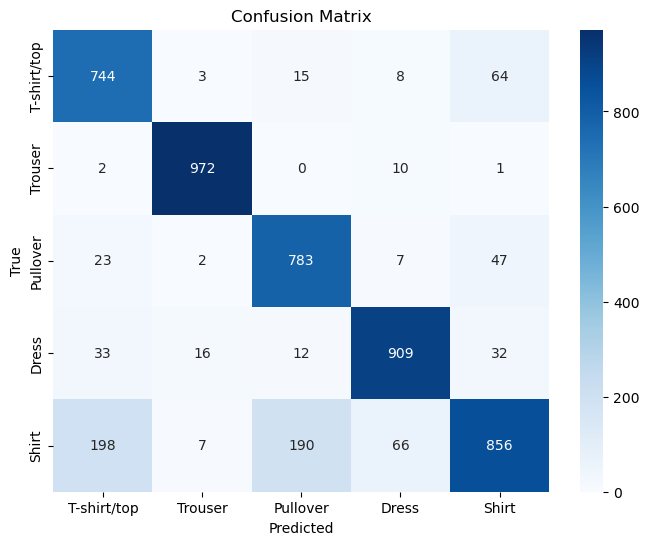

In [146]:
build_in_cnn.fit(train_data_X.reshape(-1, 28, 28,1), train_data_y, epochs=100, batch_size=32, verbose=0)
predicted_y=np.argmax(build_in_cnn.predict(test_data_X.reshape(-1, 28, 28,1)), axis=1)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix5 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix5)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix5, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()